# Problem

This notebook creates a hybrid image using frequency-domain mixing. One image contributes the low-frequency structure, while the other contributes high-frequency details. The result is a fused image whose appearance changes with the selected frequency threshold.

The workflow is:

1. Load and convert both input images to grayscale.
2. Compute centered 2D Fourier transforms.
3. Apply low-pass and high-pass frequency masks.
4. Combine the filtered spectra.
5. Reconstruct the fused image using the inverse Fourier transform.
6. Use interactive controls to vary the low-frequency image, high-frequency image, and threshold.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ipywidgets import interact, Dropdown, IntSlider

(361, 410)
(361, 410)


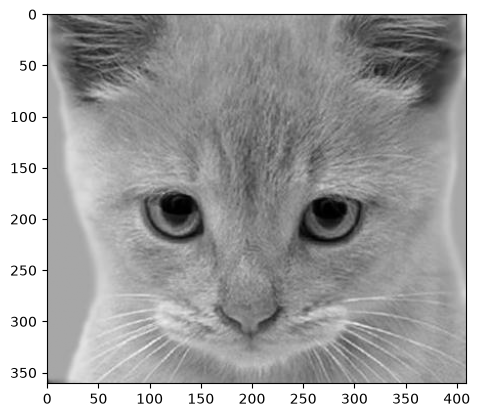

In [2]:
detail_image=Image.open("../data/cat_gray.jpg")
structure_image=Image.open("../data/dog_gray.jpg")
detail_image=detail_image.convert("L")  # Convert to grayscale
structure_image=structure_image.convert("L")  # Convert to grayscale
detail_array=np.array(detail_image)
structure_array=np.array(structure_image)
print( np.shape(structure_array))
print(np.shape(detail_array))
plt.imshow(structure_array,cmap='gray')
plt.imshow(detail_array,cmap='gray')

In [3]:
def compute_centered_fft(signal):
    fourier_transform=np.fft.fft2(signal)
    centered_fourier_transform=np.fft.fftshift(fourier_transform)
    return centered_fourier_transform 

def plot_frequency_magnitude(centered_fourier_transform):
    magnitude=np.abs(centered_fourier_transform)
    magnitude_db=20*np.log10(magnitude)
    plt.title("Magnitude in dB form") 
    plt.imshow(magnitude_db, cmap='gray')
    plt.xlabel(" Frequency X ")
    plt.ylabel(" Frequency Y ")
    plt.show() 

def inverse_centered_fft(centered_fourier_transform):
    inverse_transform=np.fft.ifft2(centered_fourier_transform)   
    return inverse_transform

In [4]:
# Create a circular low-pass mask around the centered low-frequency region.
def apply_lowpass_mask(centered_fourier_transform,threshold):
    fourier_transform=centered_fourier_transform
    x=np.array([1,0])
    y=np.array([0,1])
    shape=np.shape(fourier_transform)
    w=np.dot(shape,x)
    h=np.dot(shape,y)
    thres=threshold*w/360
    m,n= w/2,h/2 
    D=np.zeros(np.shape(fourier_transform))
    Y, X = np.indices(fourier_transform.shape)
    D = np.sqrt((X - n)**2 + (Y - m)**2)

    filtered_transform=np.where(D<=thres,fourier_transform,0)
    return filtered_transform

In [5]:
# Create a complementary circular high-pass mask for fine details.
def apply_highpass_mask(centered_fourier_transform,threshold):
    fourier_transform=centered_fourier_transform
    x=np.array([1,0])
    y=np.array([0,1])
    shape=np.shape(fourier_transform)
    w=np.dot(shape,x)
    h=np.dot(shape,y)
    thresh=threshold*w/360
    m,n= w/2,h/2 
    D=np.zeros(np.shape(fourier_transform))
    Y, X = np.indices(fourier_transform.shape)
    D = np.sqrt((X - n)**2 + (Y - m)**2)
    filtered_transform=np.where(D>=thresh,fourier_transform,0)
    return filtered_transform

In [6]:
def select_image(image_name):
    if image_name=="cat":
        return structure_array
    if image_name=="dog": 
        return detail_array

In [7]:
def frequency_mixer(low_frequency_image,high_frequency_image, threshold):
     image1= select_image(low_frequency_image)
     image2=select_image(high_frequency_image)
     image1_fft=compute_centered_fft(image1)
     image2_fft=compute_centered_fft(image2)
     mixed_frequency_transform=apply_lowpass_mask(image1_fft,threshold)+apply_highpass_mask(image2_fft,threshold)
     mixed_image=inverse_centered_fft(mixed_frequency_transform)
     plt.imshow(np.abs(mixed_image),cmap='gray')
     plt.show()
     plot_frequency_magnitude(mixed_frequency_transform)

## Frequency Mixer

The mixer combines the low-frequency part of one image with the high-frequency part of another image. Low frequencies preserve broad structure, while high frequencies preserve fine details and edges.


The interactive widget allows the threshold to be adjusted so the contribution of low and high frequencies can be explored visually. This implementation uses simple circular masks in the centered Fourier domain.


In [8]:
interact(
    frequency_mixer,
    low_frequency_image=Dropdown(
        options=["cat", "dog"],
        description="Low frequency component"
    ),
    high_frequency_image=Dropdown(
        options=["dog", "cat"],
        description="High Frequency component"
    ),
    threshold=IntSlider(
        min=1, max=360, step=1, value=1, description="Threshold"
    )
)

interactive(children=(Dropdown(description='Low frequency component', options=('cat', 'dog'), value='cat'), Dr…

<function __main__.frequency_mixer(low_frequency_image, high_frequency_image, threshold)>

## Transfer Function View

The low-pass and high-pass masks act as simple 2D transfer functions in the frequency domain. The plotted magnitude spectrum shows which frequency regions are retained after mixing.


Because the inverse Fourier transform can contain very small numerical imaginary residues, the reconstructed image is displayed using `np.abs`. This keeps the visible image real-valued without changing the frequency-mixing idea.


## Conclusion

This notebook implements a simple frequency mixer for hybrid-image creation. By combining low-frequency structure from one image with high-frequency detail from another, the fused output demonstrates how different frequency bands contribute to visual perception. The interactive threshold makes the tradeoff between structure and detail easy to explore.


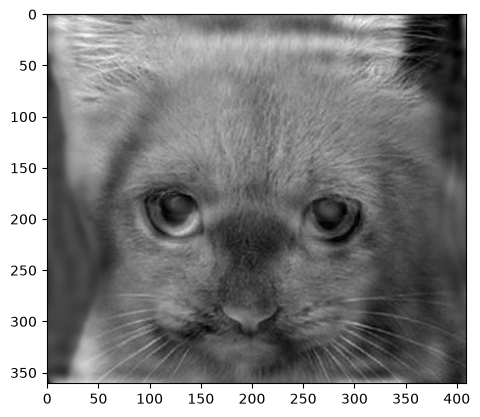

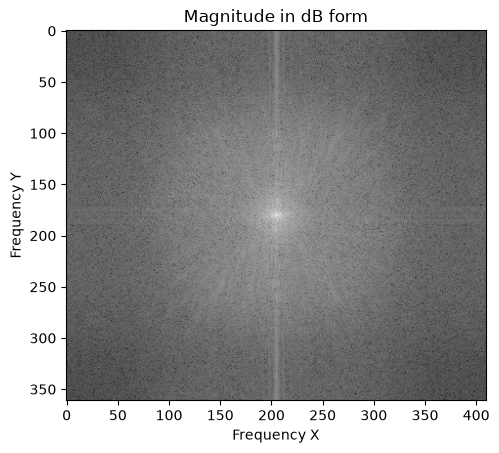

In [9]:
# Static example for GitHub portfolio rendering\n
frequency_mixer(low_frequency_image='cat', high_frequency_image='dog', threshold=17)